# Decision Tree vs Neural Network: Which Predicts Titanic Survival Better?

This is side-by-side comparison of a traditional ML model (Decision Tree) and a feedforward neural network on the same binary classification problem, following the full machine learning life cycle: problem definition, exploration and preparation of the data, training and tuning both models, then comparison and reflection.

**Dataset:** [Kaggle Competition Titanic Data Set](https://www.kaggle.com/competitions/titanic/overview)

**Label:** Whether an individual survived or not

**Question:** Is a Decision Tree or a Neural Network better for predicting survival, and is the neural network's added complexity worth it?

**Kaggle Submission Note**

Predictions from the neural network in this notebook were submitted to the [Kaggle Titanic competition](https://www.kaggle.com/competitions/titanic/overview) for leaderboard scoring against Kaggle's true holdout set (distinct from the local train/test split used for the DT vs NN comparison below). Note that the Titanic leaderboard's top scores are widely known to be inflated by leaderboard hacking (submissions using the real historical passenger manifest rather than genuine model predictions), so a legitimate score in the 0.75-0.85 range is competitive, not a top-of-leaderboard rank.

**My score:** *0.76076*

In [70]:
import pandas as pd
import numpy as np
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
import tensorflow.keras as keras
import time
from dotenv import load_dotenv
load_dotenv()
import kagglehub

# Download latest version
path = kagglehub.competition_download('titanic')

print("Path to competition files:", path)

Path to competition files: /Users/waynesimmonsjr/.cache/kagglehub/competitions/titanic


## Part 1: Load Data Set and Build DataFrame

Load dataset and inspect the first few rows.


In [71]:
# Load your dataset into df and call df.head()
data = path + "/train.csv"
df = pd.read_csv(data)

In [72]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Part 2: Define ML Problem

This project builds directly off of my Titanic EDA project which can be found [here](https://github.com/WayneS0628/titanic-eda) which explored the Titanic data set to find interesting patterns and highest predictors of whether someone survived or not.

The models developed here will be used to predict if a given person either survived (1) or did not (0).

My previous EDA project found that class and sex dominated survival so those will likely be my most important predictors of survival I plan to use.

## Part 3: EDA

A majority of code will be taken from my previous Titanic EDA project whihc again can be found on my github [here]([here](https://github.com/WayneS0628/titanic-eda)).

In [73]:
df.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [74]:
df.shape

(891, 12)

In [75]:
types_dict = {}
for column in df.columns:
    types_dict[column] = pd.api.types.infer_dtype(df[column])

types_dict

{'PassengerId': 'integer',
 'Survived': 'integer',
 'Pclass': 'integer',
 'Name': 'string',
 'Sex': 'string',
 'Age': 'floating',
 'SibSp': 'integer',
 'Parch': 'integer',
 'Ticket': 'string',
 'Fare': 'floating',
 'Cabin': 'string',
 'Embarked': 'string'}

In [76]:
df.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [77]:
df.isnull().mean()

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.198653
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.002245
dtype: float64

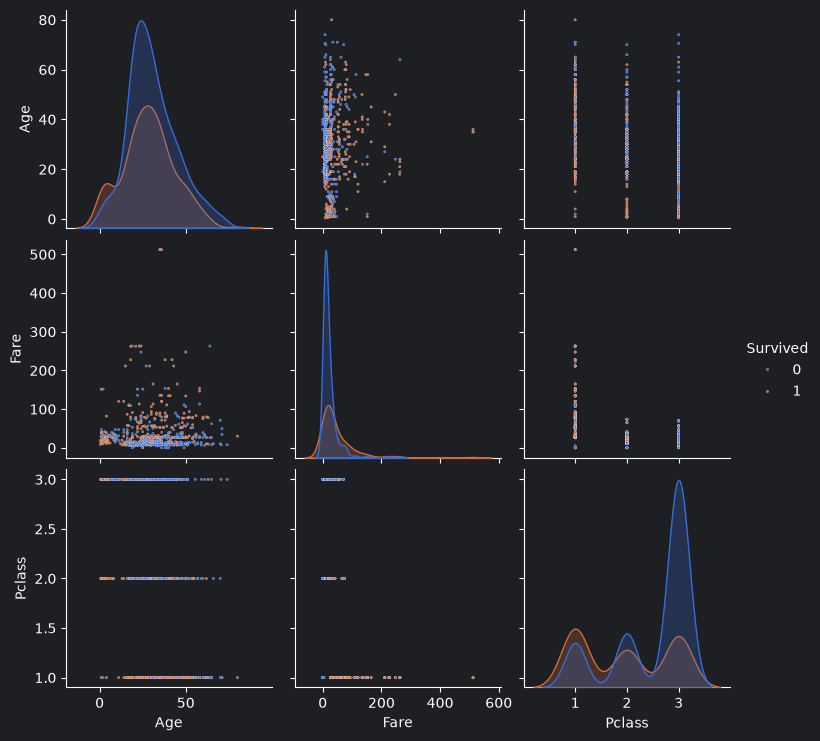

In [78]:
df_sub = df[['Age', 'Fare', 'Pclass', 'Sex', 'Embarked', 'Survived']].copy()
sns.pairplot(data=df_sub, hue='Survived', plot_kws={'s': 3})
plt.show()

In [79]:
df['Embarked'].unique()

<ArrowStringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

## Part 4: Data Prep

**Important Note**

In my initial EDA filled missing values in age with
```python
df['age'] = df['age'].fillna(df['age'].median())
```
which works by naively filling all missing values with the datasets median. I said in that project a better improvement would be to fill missing age values conditioned on sex and class which were real indicators of age. So i have done that here for better accuracy with age missing value filling.

In [80]:
# Handle missing values
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Cabin'] = df['Cabin'].fillna('Unknown')

In [81]:
# Encode categorical features (one-hot / ordinal) and drop redundant columns
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [82]:
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
df.drop(['SibSp', 'Parch'], axis=1, inplace=True)

**Design choice below: Male is 0 Female is 1**

In [84]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [85]:
df.head(50)

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Cabin,Embarked_Q,Embarked_S,Family_Size
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,A/5 21171,7.2500,Unknown,False,True,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,PC 17599,71.2833,C85,False,False,2
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,STON/O2. 3101282,7.9250,Unknown,False,True,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,113803,53.1000,C123,False,True,2
4,5,0,3,"Allen, Mr. William Henry",0,35.0,373450,8.0500,Unknown,False,True,1
5,6,0,3,"Moran, Mr. James",0,25.0,330877,8.4583,Unknown,True,False,1
6,7,0,1,"McCarthy, Mr. Timothy J",0,54.0,17463,51.8625,E46,False,True,1
7,8,0,3,"Palsson, Master. Gosta Leonard",0,2.0,349909,21.0750,Unknown,False,True,5
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",1,27.0,347742,11.1333,Unknown,False,True,3
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",1,14.0,237736,30.0708,Unknown,False,False,2


In [69]:
df.corr(numeric_only=True)['Survived'].sort_values(ascending=False)

Survived       1.000000
Sex            0.543351
Fare           0.257307
Family_Size    0.016639
Embarked_Q     0.003650
PassengerId   -0.005007
Age           -0.059579
Embarked_S    -0.149683
Pclass        -0.338481
Name: Survived, dtype: float64

### Data Preparation Summary

- Age missing values were filled with median of the group based on sex and class.
- Embarked missing values were filled with the most common value of that column
- Cabin missing values just filled with 'Unknown'
- One hot encoded Embarked to see its correlation with label
- Combined SibSp and Parch into Famil_Size sinc they both measure family
- Made sex binary for simplicity and corr matrix

### Chosen features

The features I will use for modeling based on corr matrix are Sex, Fare, Family_Size, Age, and Pclass

In [92]:
df_modeling = df[['Sex', 'Fare', 'Family_Size', 'Age', 'Pclass', 'Survived']].copy()

## Part 5: Train, Test, Evaluate, and Improve the Decision Tree

Steps:
1. Create labeled examples (`X`, `y`).
2. Split into train/test.
3. Train a baseline tree and evaluate with **accuracy and F1** (save both to variables).
4. Use `GridSearchCV` to tune hyperparameters (e.g. `max_depth`, `min_samples_leaf`).
5. Train a final tree with the best hyperparameters and evaluate on the test set.
6. Interpret the model by plotting feature importances.

In [101]:
# Create labeled examples and split into train/test
y = df_modeling['Survived']
X = df_modeling.drop('Survived', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=1234)

In [103]:
# 3. Baseline decision tree + cross-validated accuracy
model = DecisionTreeClassifier()
acc_score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
acc_mean = np.mean(acc_score)
print("Accuracy for baseline decision tree with cross validation:", acc_mean)

Accuracy for baseline decision tree with cross validation: 0.7753183229813665


In [110]:
# 4. GridSearchCV to find the best hyperparameters
model = DecisionTreeClassifier()
max_depth = [2**n for n in range(2,6)]
min_samples_leaf = [25*2**n for n in range(0, 4)]
param_grid = {'max_depth': max_depth, 'min_samples_leaf': min_samples_leaf }
grid = GridSearchCV(model, param_grid, cv = 5)
grid_search = grid.fit(X_train, y_train)
print('Optimal hyperparameters: {0}'.format(grid_search.best_params_))
print('Accuracy score: {0}'.format(grid_search.best_score_))

Optimal hyperparameters: {'max_depth': 4, 'min_samples_leaf': 50}
Accuracy score: 0.803975155279503


In [129]:
# 5. Train the final tree with the best hyperparameters, predict on test,
#    and compute BOTH accuracy and F1. Save them to variables
#    (e.g. dt_accuracy, dt_f1) for the Part 7 comparison.
best_md = grid_search.best_params_['max_depth']
best_msl = grid_search.best_params_['min_samples_leaf']

model = DecisionTreeClassifier(max_depth=best_md, min_samples_leaf=best_msl)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred)
dt_f1 = f1_score(y_test, y_pred)

print('Accuracy Score', dt_accuracy)
print('F1 Score', dt_f1)

Accuracy Score 0.8111111111111111
F1 Score 0.711864406779661


Top five features: ['Sex', 'Pclass', 'Fare', 'Age', 'Family_Size']


Text(0, 0.5, 'Normalized importance')

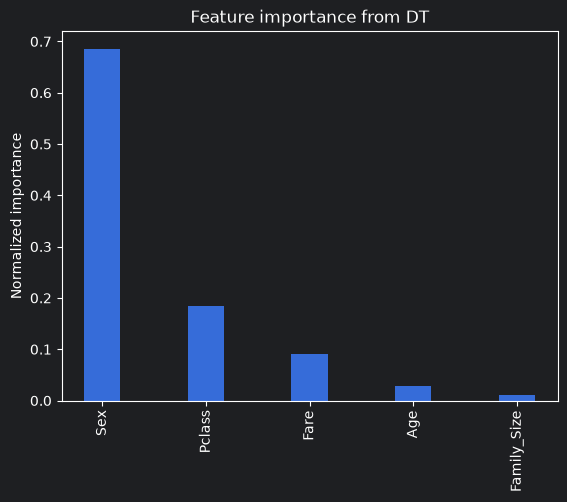

In [114]:
# 6. Interpret: get feature_importances_ and plot the top features
feature_imp = model.feature_importances_

df_features = pd.DataFrame({'name': X_train.columns.values, 'imp': feature_imp})

df_sorted = df_features.sort_values(by='imp', ascending=False)

top_five = df_sorted.iloc[:5]['name'].tolist()

print('Top five features: {0}'.format(top_five))

fig, ax = plt.subplots()
ax.bar(np.arange(5), sorted(model.feature_importances_, reverse=True)[:5], width = 0.35)
ax.set_xticks(np.arange(5))
ax.set_xticklabels(top_five, rotation = 90)
plt.title('Feature importance from DT')
ax.set_ylabel('Normalized importance')

### Decision Tree Reflection

A decision tree fits this problem well since the strongest signal here is an interaction (class and sex together producing a 95% vs 15% survival swing), and trees naturally capture that kind of threshold-based "if this AND that" logic. Grid search moved cross-validated accuracy from 0.775 (baseline) to 0.804 (tuned), landing on max_depth=4 and min_samples_leaf=50, telling me the untuned tree was overfitting noise in this small (891-row) dataset and constraining it to simpler splits actually helped. Feature importances (Sex, Pclass, Fare, Age, Family_Size) line up almost exactly with what my original EDA flagged as the top predictors, a good sanity check that modeling didn't contradict exploration. One fairness note: the tree is explicitly learning that sex and class predict survival, which is historically accurate for this specific event but would be a serious problem if generalized to a different context like lending or hiring.

## Part 6: Train, Test, Evaluate, and Improve a Neural Network

Now we build a feedforward neural network in Keras for the same problem, so we can compare it head-to-head with the tree.

### Prepare (Scale) Your Data for the Neural Network

In [115]:
# Create the scaler, fit_transform on X_train, transform on X_test

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train mean (should be ~0):", np.round(X_train_scaled.mean(), 6))
print("Train std  (should be ~1):", np.round(X_train_scaled.std(), 6))
print("Test mean  (close to 0, not exactly 0 — expected):", np.round(X_test_scaled.mean(), 4))

Train mean (should be ~0): 0.0
Train std  (should be ~1): 1.0
Test mean  (close to 0, not exactly 0 — expected): 0.015


### Step 1: Define the Model Architecture

In [116]:
n_features = X_train_scaled.shape[1]

nn_model = keras.Sequential()

# Input layer
input_layer = keras.layers.InputLayer(shape=(n_features,), name='input')
nn_model.add(input_layer)


hidden_layer_1 = keras.layers.Dense(units=64, activation='relu', name='hl_1')
nn_model.add(hidden_layer_1)


hidden_layer_2 = keras.layers.Dense(units=32, activation='relu', name='hl_2')
nn_model.add(hidden_layer_2)


hidden_layer_3 = keras.layers.Dense(units=16, activation='relu', name='hl_3')
nn_model.add(hidden_layer_3)

# Output layer
output_layer = keras.layers.Dense(units=1, activation='sigmoid', name='output')
nn_model.add(output_layer)

nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hl_1 (Dense)                    │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hl_2 (Dense)                    │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hl_3 (Dense)                    │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

### Step 2: Define the Optimizer

In [117]:
sgd_optimizer = keras.optimizers.SGD(learning_rate=0.1)

### Step 3: Define the Loss Function

In [118]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

In [119]:
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=['accuracy'])

### Step 5: Fit the Model

We will run the logger cell below first, then fit the model.

In [120]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):

    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))

In [121]:
t0 = time.time()

num_epochs = 200
history = nn_model.fit(X_train_scaled, y_train, epochs=num_epochs,
                       validation_split=0.2,
                       callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=50)],
                       verbose=0)


t1 = time.time()
print('Elapsed time: %.2fs' % (t1-t0))

Epoch [50/ 200], Accuracy: 0.8406, Loss: 0.3821, Val_accuracy: 0.8012, Val_loss: 0.4219
Epoch [100/ 200], Accuracy: 0.8422, Loss: 0.3650, Val_accuracy: 0.8137, Val_loss: 0.4055
Epoch [150/ 200], Accuracy: 0.8469, Loss: 0.3501, Val_accuracy: 0.8323, Val_loss: 0.4182
Epoch [200/ 200], Accuracy: 0.8484, Loss: 0.3458, Val_accuracy: 0.8199, Val_loss: 0.4166
Elapsed time: 7.70s


### Step 6: Visualize Training Performance

Plot (1) training vs validation loss and (2) training vs validation accuracy over epochs, each on shared axes with labels and a legend

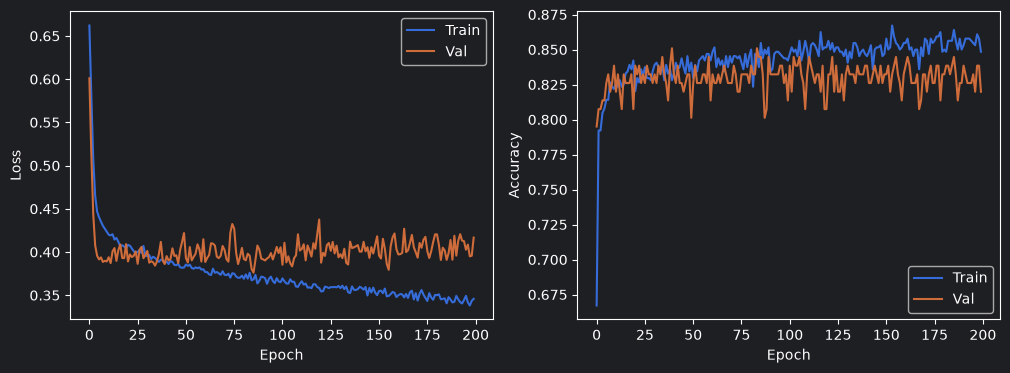

In [124]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'])
axes[0].plot(history.history['val_loss'])

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(['Train', 'Val'])

axes[1].plot(history.history['accuracy'])
axes[1].plot(history.history['val_accuracy'])

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(['Train', 'Val'])

### Step 7: Evaluate on the Test Set

`nn_model.predict()` returns probabilities — threshold at 0.5 for class labels. Compute **accuracy and F1** and save them to clearly named variables (e.g. `nn_accuracy`, `nn_f1`) for the comparison.

In [125]:
y_pred_proba = nn_model.predict(X_test_scaled)
y_pred_nn = (y_pred_proba > 0.5).astype(int)
print(y_pred_nn)

nn_accuracy = accuracy_score(y_test, y_pred_nn)
nn_f1 = f1_score(y_test, y_pred_nn)

print('Accuracy Score', nn_accuracy)
print('F1 Score', nn_f1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
[[1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]]
Accuracy Score 0.8666666666666667
F1 Score 0.8181818181818182


### Neural Network Reflection

Three hidden layers (64, 32, 16 units) with ReLU activations funnel into a single sigmoid output for binary classification, trained with SGD at a 0.1 learning rate for 200 epochs (7.7 seconds total), chosen to converge quickly on a small dataset without excessive runtime. By epoch 200, train accuracy sat at 0.848 versus val accuracy at 0.820 with a similar gap in loss (0.346 vs 0.417), a real but modest split indicating mild overfitting rather than anything severe, since both curves were still trending the right direction instead of diverging. On the test set the model hit 0.867 accuracy and 0.818 F1, both a bit higher than the validation curves alone predicted, a pleasant surprise suggesting an easier test split rather than an unstable model.

## Part 7: Compare Your Models and Reflect

### Results Summary

In [128]:
results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score'],
    'Decision Tree': [dt_accuracy, dt_f1],
    'Neural Network': [nn_accuracy, nn_f1]
})
print(results.to_string(index=False))

  Metric  Decision Tree  Neural Network
Accuracy       0.811111        0.866667
F1 Score       0.711864        0.818182


### Comparative Analysis

The neural network won on both metrics, and the gap isn't small: accuracy 0.867 vs 0.811 (a 5.6 point edge) and F1 0.818 vs 0.712 (a 10.6 point edge), with the F1 gap mattering most since it shows the NN is genuinely better at catching survivors rather than just riding class imbalance to a good accuracy score. That complexity earned its keep here: training took 7.7 seconds, so the usual cost argument against NNs barely applies, and a 10-point F1 swing on a life-or-death classification problem is not a rounding error. For this specific problem I'd deploy the neural network on pure performance, though I'd lean toward the decision tree instead in any regulated or high-stakes explainability context, since its feature importances give a clean, human-readable story ("sex and class mattered most") that the NN can't. Next steps I'd actually pursue: benchmark against a random forest before crowning the NN the winner, since a single tree is a weak baseline; handle the roughly 62/38 class imbalance more deliberately with class weights or a tuned threshold instead of a flat 0.5 cutoff; and try Adam plus dropout on the NN side along with engineered features like title extracted from name, which my EDA flagged as promising but never tested here.

## Conclusion

 For predicting Titanic survival, the neural network outperformed the decision tree on both accuracy (0.867 vs 0.811) and F1 (0.818 vs 0.712), and the F1 gap in particular shows it wasn't just exploiting class imbalance, it was actually better at identifying who survived. Given how cheap training was at this data scale (under 8 seconds), the added architectural complexity was clearly worth it here. That said, the decision tree isn't a loser in this story: it hit respectable numbers with a fraction of the setup and handed over a fully interpretable feature ranking that confirmed sex and class were the dominant survival factors, exactly what my original EDA found. If I had to pick one model to explain to a non-technical stakeholder, I'd reach for the tree. If I had to pick one model to actually deploy and trust with predictions, it's the neural network.